# Machine Learning for Business

## Introduction

Bike-sharing is popular in cities. But the number of rentals changes every day because of weather, season and holidays. This makes planning difficult for companies.
This project uses the UCI Bike Sharing dataset (Fanaee-T and Gama, 2013). It has 731 days of data from Washington D.C. (2011–2012).
Objectives:
Group similar days with K-Means and Hierarchical clustering, and compare them.
Give simple advice to the company.

In [1]:
#So before doing any analysis i need to load the tools.
#Without these libraries i cannot read files, create charts or build models.
#This is always the first step in any data science project.
import pandas as pd #for reading and working with structured data.
import seaborn as sns #for creating clear, informative. 
import matplotlib.pyplot as plt #for charts and graphs.
import numpy as np #for numerical operations and data manipulation
import warnings 
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('day.csv')

In [3]:
# I used this code to display the first 5 rows of the dataset.
# i know, this helps me quickly check that the file loaded
# correctly and that the column names and values look as expected.
# It is always good practice to visually inspect the data
# before starting any analysis.
df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [4]:

# i need to know the size of our dataset.
# This code tells me how many rows (observations) and columns (features) we have.
df.shape

(731, 16)

I found that the dataset has 731 rows and 16 columns.

So this is important because before cleaning data, i must understand the structure of the dataset.

In [5]:
# Display data types and non-null counts for each column.
# This code is important to identify which columns are numeric (int/float)
# and which are categorical (object), and to spot columns with missing values.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [9]:
# I used this code to get a statistical summary of all numeric columns.
# It shows the mean, min, max, standard deviation and quartiles.
# This helps me understand the range of each variable and spot
# any unusual values before clustering and time series analysis.
df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


### Variable types
The dataset contains different types of variables:
- Categorical: season, yr, mnth, holiday, weekday, workingday, weathersit
- Continuous: temp, atemp, hum, windspeed
- Discrete (counts): casual, registered, cnt
- Date: dteday
- Identifier: instant (row number, not used in the analysis)

As we can see, the dataset has 16 columns with categorical, continuous and discrete
variables, which meets the requirement of at least 7 columns of different types.

Then i need to check if i have any missing values. Missing values are important because:

they can reduce model accuracy

they can affect statistical analysis

they must be cleaned before machine learning

In [7]:
df.isnull().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

I checked and i dont have any missinf values

In [8]:
# i will check duplicates to ensure data consistency and reliability.
# Duplicate rows can skew analysis and model training by giving
# certain observations more weight than they deserve.
df.duplicated().sum()

np.int64(0)

I saw The result showed that the dataset contained no duplicate observations; therefore, no rows were removed.

In [10]:
# I converted the date column to date format because pandas reads it as text.
# This is needed to plot the data over time and later for the SARIMA model.
df['dteday'] = pd.to_datetime(df['dteday'])

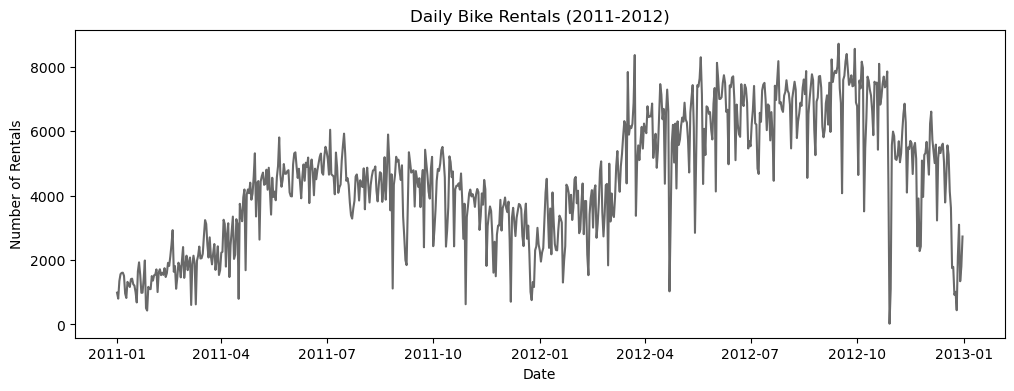

In [11]:
# I used a line plot to show the daily rentals over the two years.
# The purpose of this is to see the trend (growth over time) and the
# seasonality (higher in summer, lower in winter) before the time series part.
plt.figure(figsize = (12, 4))
plt.plot(df['dteday'], df['cnt'], color = 'dimgray')
plt.title('Daily Bike Rentals (2011-2012)')
plt.xlabel('Date')
plt.ylabel('Number of Rentals')
plt.show()

From this plot i see , daily rentals increase from 2011 to 2012, which shows an upward trend.
Rentals are higher in summer and lower in winter, which shows a yearly seasonality.
There are also some days with very low rentals, probably because of bad weather or holidays.